# **EDA Dataset Plagas y Enfermedades en la Vid**

#### **LIBRERÍAS**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import math
import scipy.stats as stats

#### **CARGA DE DATOS**

Importamos el conjunto de datos preprocesado (para obtenerlo hay que ejecutar el flujo del simulador y el script preprocess.py)

In [2]:
df = pd.read_parquet("../../data/processed/data_vin_processed.parquet")

# Mostramos todas las columnas del dataset en crudo:
pd.set_option('display.max_columns', None)
display(df.head())

# 1. Asegurar formato Datetime
df['Fecha'] = pd.to_datetime(df['Fecha'])

# 2. Extraer componentes temporales reales
df['Mes'] = df['Fecha'].dt.month
df['Dia'] = df['Fecha'].dt.day
df['Hora_Dia'] = df['Fecha'].dt.hour

# 3. Crear 'Tiempo_Continuo_Dias' para las gráficas
# Como cada planta empezó un día distinto de la primavera, para dibujar las curvas 
# de infección alineadas desde cero, calculamos los días transcurridos para cada planta.
df['Tiempo_Continuo_Dias'] = df.groupby('ID_Serie')['Fecha'].transform(
    lambda x: (x - x.min()).dt.total_seconds() / 3600 / 24
)

,CO2_ppm,Clase_Entrenamiento,Etiqueta_Clase,Fecha,Grado_Infeccion,Hum_Rel_Pct,Hum_Suelo_Pct,ID_Serie,Lluvia_mm,Parcela_ID,Temp_Amb_C,VOC_ppb,Viento_kmh,pH_Suelo,Hora,Hora_Sin,Hora_Cos,GDD_Acumulado,Horas_Humedad_Foliar
0,398.813232,HEALTHY,LOBESIA,2023-04-19 18:00:00,0.005047,21.0,28.960115,0,0.0,ribera_del_duero,23.299999,61.444447,8.0,6.904538,18,-1.000000,-1.836970e-16,5.883334,0.0
1,397.811279,HEALTHY,LOBESIA,2023-04-19 19:00:00,0.005047,20.0,28.955692,0,0.0,ribera_del_duero,23.000000,74.952682,6.9,6.912406,19,-0.965926,2.588190e-01,5.883334,0.0
2,439.846436,HEALTHY,LOBESIA,2023-04-19 20:00:00,0.005047,34.0,28.953594,0,0.0,ribera_del_duero,21.200001,83.156921,4.3,6.904041,20,-0.866025,5.000000e-01,5.883334,0.0
3,426.677887,HEALTHY,LOBESIA,2023-04-19 21:00:00,0.005047,31.0,28.953119,0,0.0,ribera_del_duero,17.700001,53.178280,7.8,6.925395,21,-0.707107,7.071068e-01,5.883334,0.0
4,423.542206,HEALTHY,LOBESIA,2023-04-19 22:00:00,0.005047,33.0,28.953119,0,0.0,ribera_del_duero,16.100000,62.143723,8.3,6.900627,22,-0.500000,8.660254e-01,5.883334,0.0


## **Análisis Exploratorio**

**VISUALIZACIÓN DE ESTADÍSTICAS**

In [3]:
# --- Verificación preliminar ---
print("Primeras filas:")
display(df.head(3))

print("\nUltimas filas:")
display(df.tail(3))

print("\nInformación de columnas:")
print(df.info())

print("\nDescripción estadística del dataset:")
print(df.describe())

Primeras filas:


,CO2_ppm,Clase_Entrenamiento,Etiqueta_Clase,Fecha,Grado_Infeccion,Hum_Rel_Pct,Hum_Suelo_Pct,ID_Serie,Lluvia_mm,Parcela_ID,Temp_Amb_C,VOC_ppb,Viento_kmh,pH_Suelo,Hora,Hora_Sin,Hora_Cos,GDD_Acumulado,Horas_Humedad_Foliar,Mes,Dia,Hora_Dia,Tiempo_Continuo_Dias
0,398.813232,HEALTHY,LOBESIA,2023-04-19 18:00:00,0.005047,21.0,28.960115,0,0.0,ribera_del_duero,23.299999,61.444447,8.0,6.904538,18,-1.000000,-1.836970e-16,5.883334,0.0,4,19,18,0.000000
1,397.811279,HEALTHY,LOBESIA,2023-04-19 19:00:00,0.005047,20.0,28.955692,0,0.0,ribera_del_duero,23.000000,74.952682,6.9,6.912406,19,-0.965926,2.588190e-01,5.883334,0.0,4,19,19,0.041667
2,439.846436,HEALTHY,LOBESIA,2023-04-19 20:00:00,0.005047,34.0,28.953594,0,0.0,ribera_del_duero,21.200001,83.156921,4.3,6.904041,20,-0.866025,5.000000e-01,5.883334,0.0,4,19,20,0.083333



Ultimas filas:


,CO2_ppm,Clase_Entrenamiento,Etiqueta_Clase,Fecha,Grado_Infeccion,Hum_Rel_Pct,Hum_Suelo_Pct,ID_Serie,Lluvia_mm,Parcela_ID,Temp_Amb_C,VOC_ppb,Viento_kmh,pH_Suelo,Hora,Hora_Sin,Hora_Cos,GDD_Acumulado,Horas_Humedad_Foliar,Mes,Dia,Hora_Dia,Tiempo_Continuo_Dias
1628658,409.790802,OIDIO,OIDIO,2018-08-16 23:00:00,1.0,50.0,25.947443,988,0.0,rueda,23.799999,11.659007,25.500000,6.781399,23,-0.258819,0.965926,344.741638,0.0,8,16,23,23.166667
1628659,410.395142,OIDIO,OIDIO,2018-08-17 00:00:00,1.0,63.0,25.947443,988,0.0,rueda,21.400000,5.852720,21.900000,6.777717,0,0.000000,1.000000,344.741638,0.0,8,17,0,23.208333
1628660,404.585663,OIDIO,OIDIO,2018-08-17 01:00:00,1.0,69.0,25.947443,988,0.0,rueda,20.100000,12.209346,23.700001,6.813069,1,0.258819,0.965926,344.741638,0.0,8,17,1,23.250000



Información de columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1628661 entries, 0 to 1628660
Data columns (total 23 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   CO2_ppm               1628661 non-null  float32       
 1   Clase_Entrenamiento   1628661 non-null  object        
 2   Etiqueta_Clase        1628661 non-null  object        
 3   Fecha                 1628661 non-null  datetime64[ns]
 4   Grado_Infeccion       1628661 non-null  float32       
 5   Hum_Rel_Pct           1628661 non-null  float32       
 6   Hum_Suelo_Pct         1628661 non-null  float32       
 7   ID_Serie              1628661 non-null  int64         
 8   Lluvia_mm             1628661 non-null  float32       
 9   Parcela_ID            1628661 non-null  object        
 10  Temp_Amb_C            1628661 non-null  float32       
 11  VOC_ppb               1628661 non-null  float32       
 12  Viento_kmh      

**DATOS DUPLICADOS Y NULOS**

In [4]:
import pandas as pd

def comprobar_duplicados(df: pd.DataFrame) -> pd.DataFrame:
    """
    Comprueba si hay filas duplicadas en un DataFrame de pandas.
    
    Args:
        df: DataFrame a analizar.
        
    Returns:
        Un DataFrame que contiene solo las filas que están duplicadas 
        (mostrando todas las apariciones para poder compararlas), 
        o None si no hay duplicados.
    """
    # Contar cuántas filas están duplicadas
    num_duplicados = df.duplicated().sum()
    
    if num_duplicados > 0:
        print(f"⚠️ Se encontraron {num_duplicados} filas duplicadas en el dataset.")
        
        # Filtramos para ver TODAS las filas involucradas en el duplicado (keep=False)
        # y las ordenamos para ver las filas idénticas juntas
        filas_duplicadas = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
        return filas_duplicadas
    else:
        print("✅ No se encontraron filas duplicadas en el dataset.")
        return None

# Datos duplicados:
df_duplicados = comprobar_duplicados(df)
if df_duplicados is not None:
    display(df_duplicados)

# Datos nulos:
null_counts = df.isnull().sum()
if null_counts.sum() > 0:
    print("\n⚠️ Valores Nulos detectados:\n", null_counts[null_counts > 0])
else:
    print("\n✅ No se han detectado valores nulos.")

✅ No se encontraron filas duplicadas en el dataset.

✅ No se han detectado valores nulos.


No hay ningún tipo de dato duplicado o nulo en el conjunto de datos

**DISTRIBUCIONES**

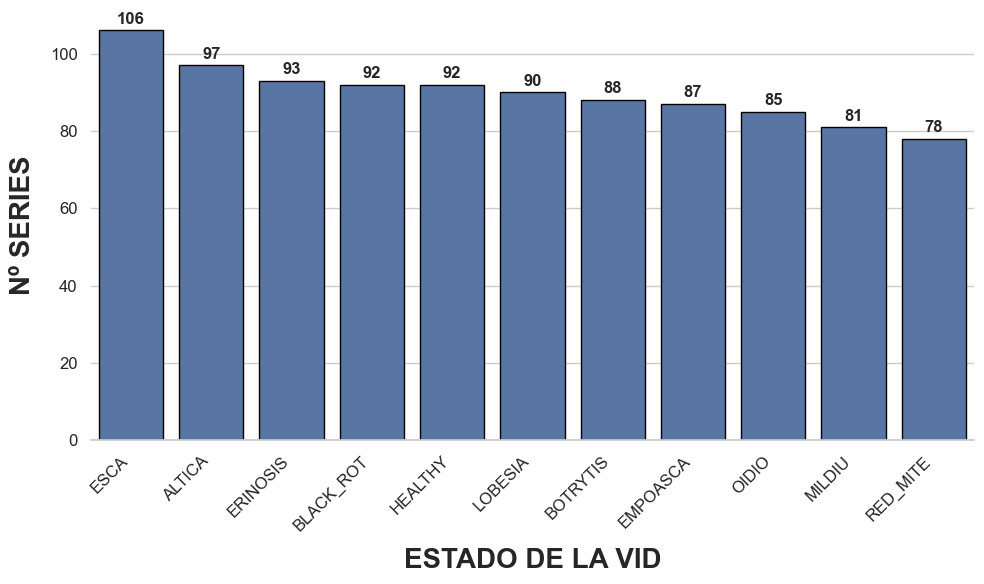

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# CONFIGURACIÓN DE TAMAÑOS Y ESTILOS
# =============================================================================
SIZE_TITLE = 16        # Tamaño del título principal
SIZE_LABELS = 20       # Tamaño de los ejes (X e Y)
SIZE_TICKS = 12        # Tamaño de los textos de las categorías y números de los ejes
SIZE_ANNOTATIONS = 12  # Tamaño de los números que aparecen encima de las barras
COLOR_BARS = '#4C72B0' # Color de las barras (Hexadecimal)
FIG_SIZE = (10, 6)     # Tamaño de la figura (ancho, alto)

# =============================================================================
# ANÁLISIS DE DISTRIBUCIÓN (BALANCEO)
# =============================================================================
sns.set_theme(style="whitegrid", font_scale=1) # Reiniciamos la escala base

df_unicos = df.drop_duplicates(subset=['ID_Serie'])
conteo_series = df_unicos['Etiqueta_Clase'].value_counts()

fig, ax = plt.subplots(figsize=FIG_SIZE)

barplot = sns.barplot(
    x=conteo_series.index, 
    y=conteo_series.values, 
    color=COLOR_BARS,
    ax=ax,
    edgecolor='black',
    linewidth=1
)

# Añadir el número exacto encima de cada barra
for p in barplot.patches:
    barplot.annotate(
        format(p.get_height(), '.0f'), 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', 
        xytext=(0, 8), 
        textcoords='offset points',
        fontsize=SIZE_ANNOTATIONS,
        fontweight='bold'
    )

# Aplicar los tamaños configurados a títulos y etiquetas
#ax.set_title('Distribución de Series Únicas por Patología', fontsize=SIZE_TITLE, fontweight='bold', pad=15)
ax.set_xlabel('ESTADO DE LA VID', fontsize=SIZE_LABELS, fontweight='bold', labelpad=10)
ax.set_ylabel('Nº SERIES', fontsize=SIZE_LABELS, fontweight='bold', labelpad=10)

# Aplicar tamaños a los "ticks" (las categorías en X y los números en Y)
plt.xticks(rotation=45, ha='right', fontsize=SIZE_TICKS)
plt.yticks(fontsize=SIZE_TICKS)

sns.despine(left=True, bottom=False)
plt.tight_layout()

# Guardar la figura en alta resolución (PDF o PNG a 300 dpi)
plt.savefig('figuras/distribucion_clases.png', dpi=300, format='png', bbox_inches='tight')

plt.show()

Se observa en el diagrama de frecuencias únicas por ID, que el dataset está balanceado, por lo tanto no hay que realizar ningún muestreo y podremos trabajar directamente sobre los datos.

**Balanceo de clases por parcela**

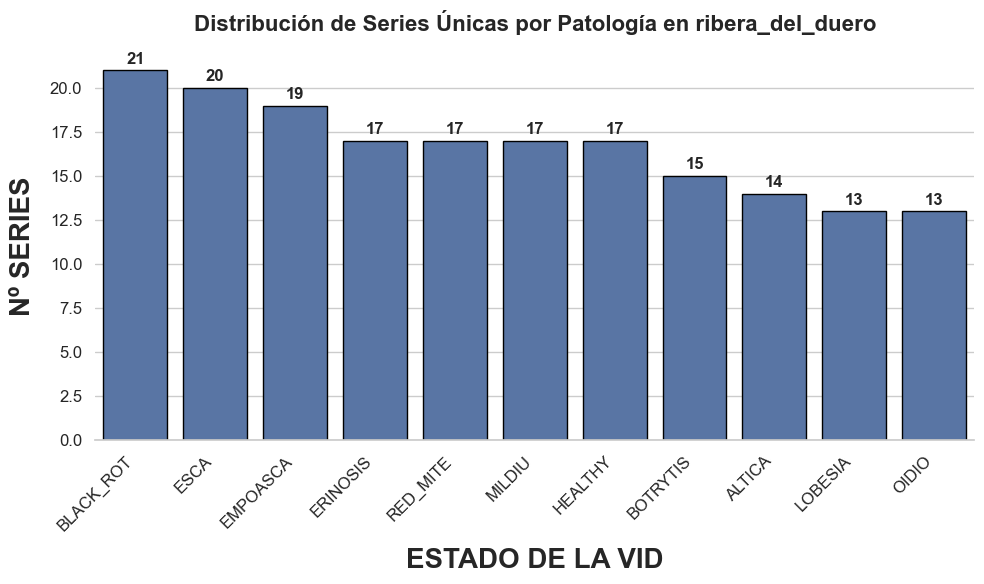

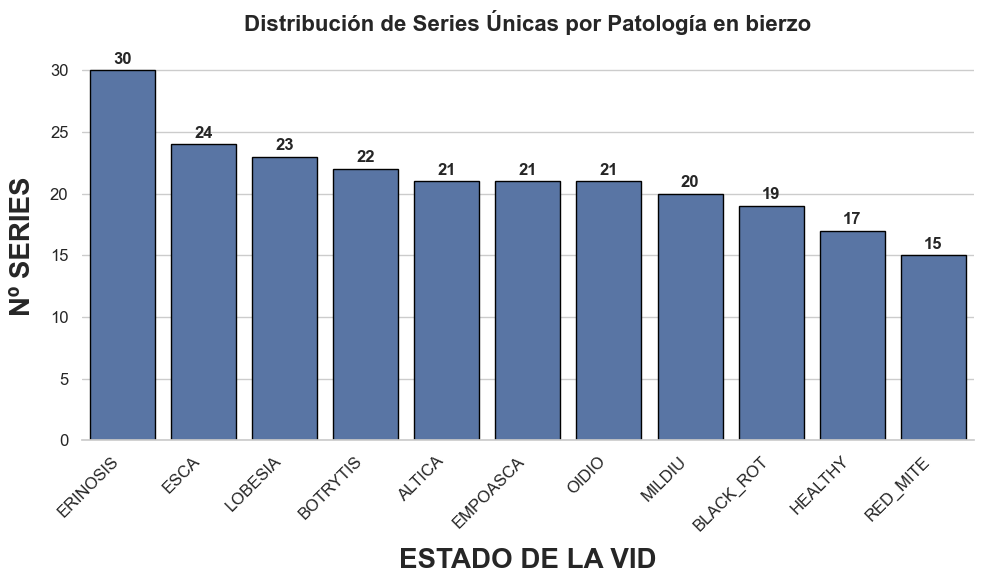

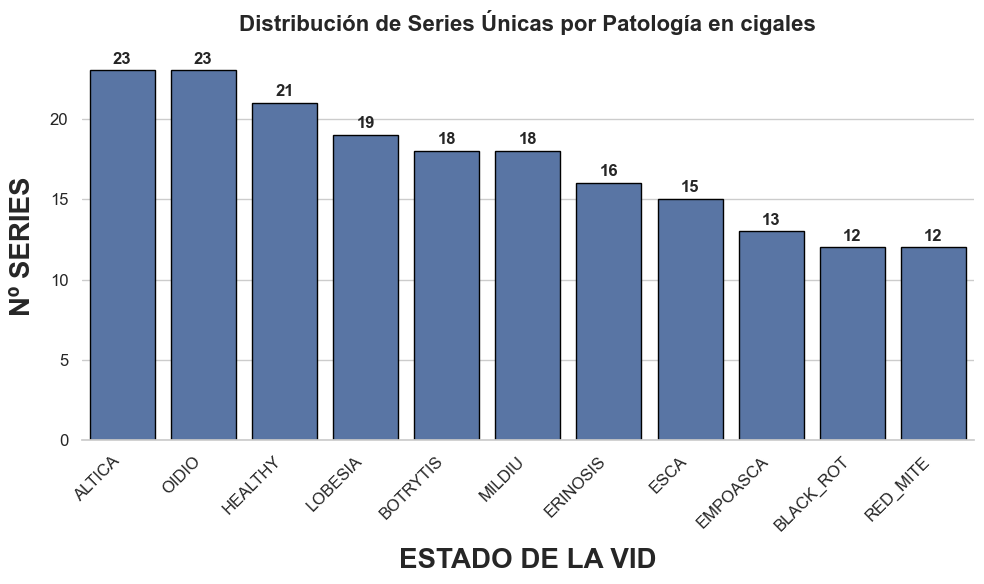

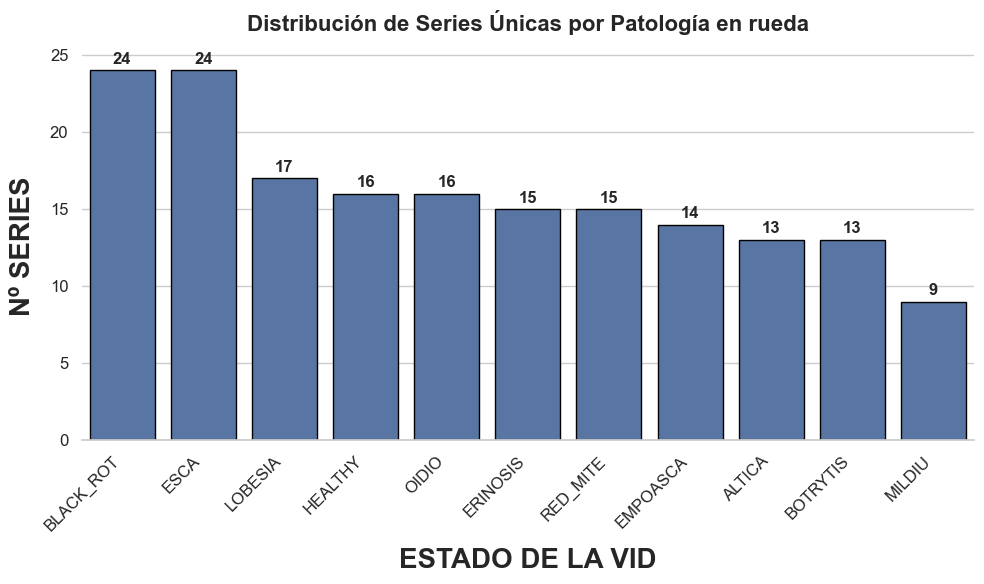

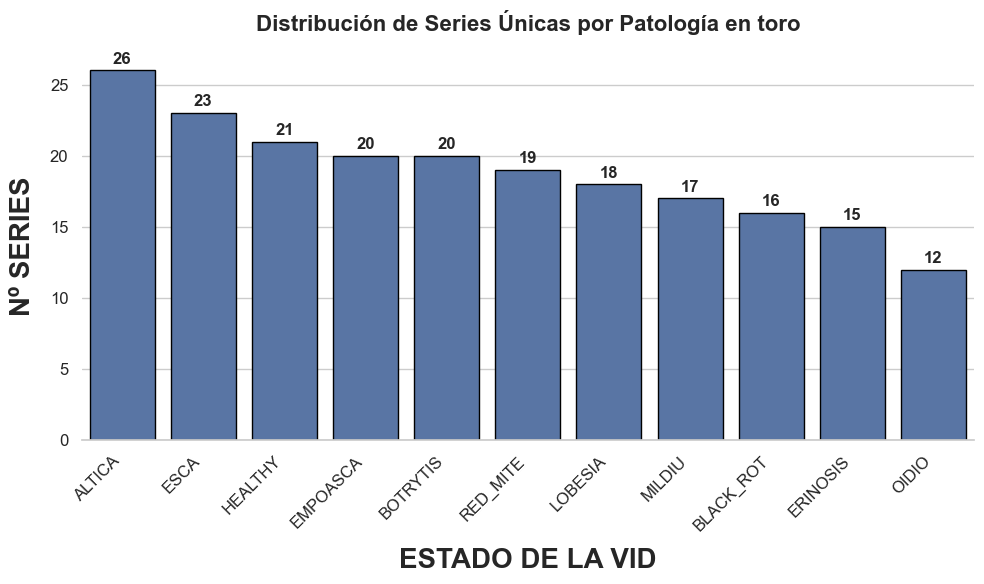

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# CONFIGURACIÓN DE TAMAÑOS Y ESTILOS
# =============================================================================
SIZE_TITLE = 16        # Tamaño del título principal
SIZE_LABELS = 20       # Tamaño de los ejes (X e Y)
SIZE_TICKS = 12        # Tamaño de los textos de las categorías y números de los ejes
SIZE_ANNOTATIONS = 12  # Tamaño de los números que aparecen encima de las barras
COLOR_BARS = '#4C72B0' # Color de las barras (Hexadecimal)
FIG_SIZE = (10, 6)     # Tamaño de la figura (ancho, alto)

# =============================================================================
# ANÁLISIS DE DISTRIBUCIÓN DE PARCELAS ID (BALANCEO)
# =============================================================================
sns.set_theme(style="whitegrid", font_scale=1) # Reiniciamos la escala base

for parcela in df["Parcela_ID"].unique():

    df_parcela = df[df["Parcela_ID"] == parcela].copy()
    df_unicos = df_parcela.drop_duplicates(subset=['ID_Serie'])
    conteo_series = df_unicos['Etiqueta_Clase'].value_counts()

    fig, ax = plt.subplots(figsize=FIG_SIZE)

    barplot = sns.barplot(
        x=conteo_series.index, 
        y=conteo_series.values, 
        color=COLOR_BARS,
        ax=ax,
        edgecolor='black',
        linewidth=1
    )

    # Añadir el número exacto encima de cada barra
    for p in barplot.patches:
        barplot.annotate(
            format(p.get_height(), '.0f'), 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', va='center', 
            xytext=(0, 8), 
            textcoords='offset points',
            fontsize=SIZE_ANNOTATIONS,
            fontweight='bold'
        )

    # Aplicar los tamaños configurados a títulos y etiquetas
    ax.set_title(f'Distribución de Series Únicas por Patología en {parcela}', fontsize=SIZE_TITLE, fontweight='bold', pad=15)
    ax.set_xlabel('ESTADO DE LA VID', fontsize=SIZE_LABELS, fontweight='bold', labelpad=10)
    ax.set_ylabel('Nº SERIES', fontsize=SIZE_LABELS, fontweight='bold', labelpad=10)

    # Aplicar tamaños a los "ticks" (las categorías en X y los números en Y)
    plt.xticks(rotation=45, ha='right', fontsize=SIZE_TICKS)
    plt.yticks(fontsize=SIZE_TICKS)

    sns.despine(left=True, bottom=False)
    plt.tight_layout()

    # Guardar la figura en alta resolución (PDF o PNG a 300 dpi)
    plt.savefig('figuras/distribucion_clases.png', dpi=300, format='png', bbox_inches='tight')

    plt.show()

**Gráficas de Infección**

Observemos cómo de rápido se expande una enfermedad/plaga en función de cada Etiqueta_Clase y del tiempo:

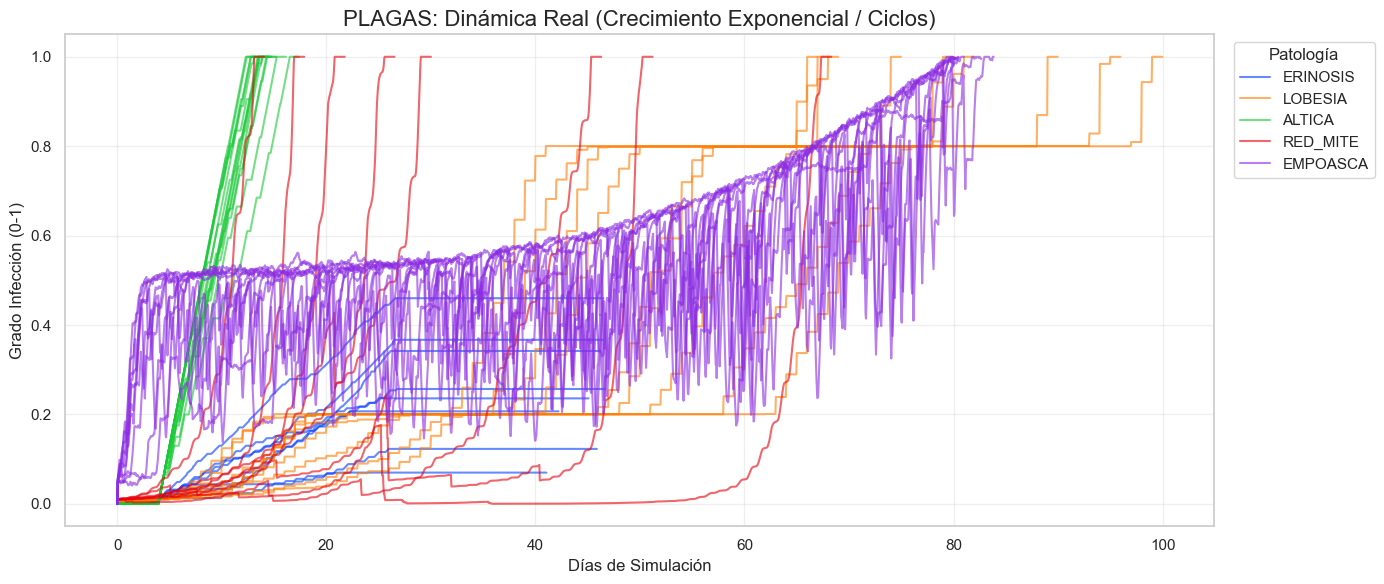

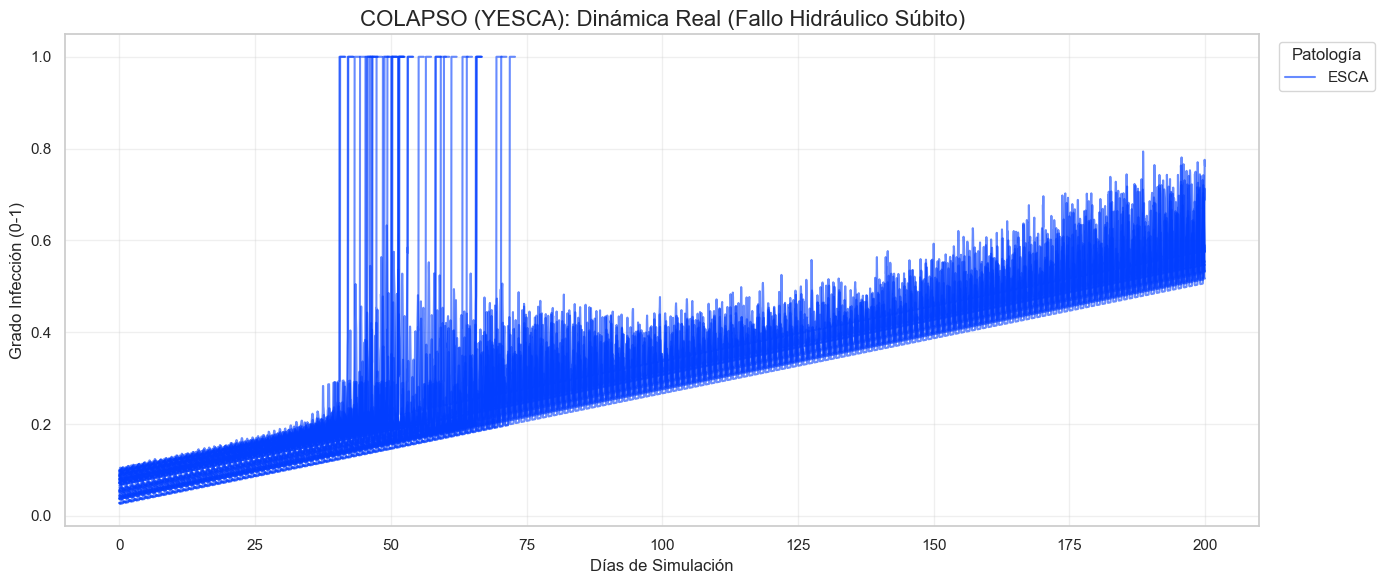

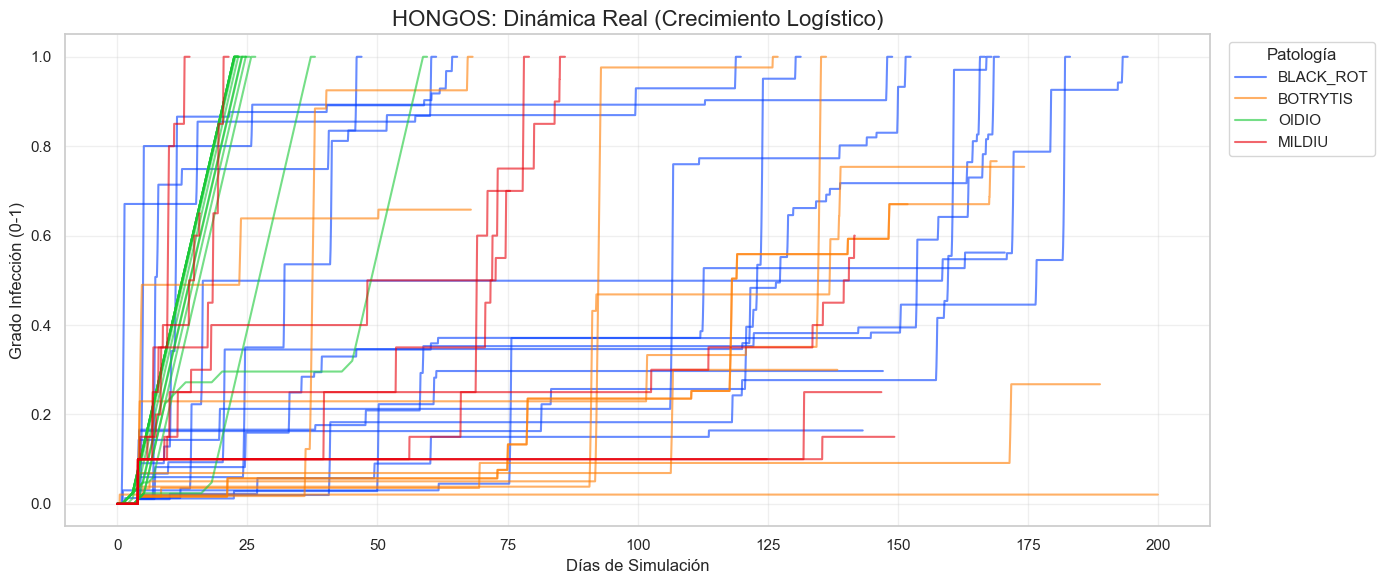

In [7]:
# =============================================================================
# GRÁFICAS DE PROGRESIÓN DE INFECCIÓN (CORREGIDAS: TRAYECTORIAS INDIVIDUALES)
# =============================================================================

plagas = ["LOBESIA", "ALTICA", "EMPOASCA", "RED_MITE", "ERINOSIS"]
colapso = ["ESCA"]
hongos = ["MILDIU", "BLACK_ROT", "OIDIO", "BOTRYTIS"]

# --- FUNCIÓN DE VISUALIZACIÓN DE TRAYECTORIAS ---
def plot_trayectorias_reales(df_origen, lista_clases, titulo, n_muestras=50):
    df_filtrado = df_origen[df_origen['Etiqueta_Clase'].isin(lista_clases)].copy()
    
    ids_unicos = df_filtrado['ID_Serie'].unique()
    if len(ids_unicos) > n_muestras:
        ids_seleccionados = np.random.choice(ids_unicos, n_muestras, replace=False)
        df_plot = df_filtrado[df_filtrado['ID_Serie'].isin(ids_seleccionados)]
    else:
        df_plot = df_filtrado

    plt.figure(figsize=(14, 6))
    sns.lineplot(
        data=df_plot, 
        x="Tiempo_Continuo_Dias", 
        y="Grado_Infeccion", 
        hue="Etiqueta_Clase", 
        units="ID_Serie",      
        estimator=None,        
        alpha=0.6,             
        linewidth=1.5,
        palette="bright"
    )
    
    plt.title(titulo, fontsize=16)
    plt.ylabel('Grado Infección (0-1)')
    plt.xlabel('Días de Simulación')
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title="Patología")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- A) PLAGAS (Deben verse curvas exponenciales y picos generacionales) ---
plot_trayectorias_reales(
    df, 
    plagas, 
    'PLAGAS: Dinámica Real (Crecimiento Exponencial / Ciclos)'
)

# --- B) COLAPSO / YESCA (Deben verse líneas planas que saltan a 1.0 verticalmente) ---
plot_trayectorias_reales(
    df, 
    colapso, 
    'COLAPSO (YESCA): Dinámica Real (Fallo Hidráulico Súbito)'
)

# --- C) HONGOS (Deben verse curvas Sigmoides / forma de "S") ---
plot_trayectorias_reales(
    df, 
    hongos, 
    'HONGOS: Dinámica Real (Crecimiento Logístico)'
)

## **Comprobación de VOC y CO2**

🔍 EVALUACIÓN DE SEÑAL PREDICTIVA Y SEPARABILIDAD DE CLASES

1. Analizamos la correlación lineal entre infección y predictoras:
  Correlación con Grado_Infeccion:
      ✅ RUIDO SANO    CO2_ppm: +0.117
      ✅ RUIDO SANO    GDD_Acumulado: +0.255
      ✅ RUIDO SANO    Horas_Humedad_Foliar: +0.038
      ✅ RUIDO SANO    Hum_Rel_Pct: +0.023
      ✅ RUIDO SANO    Hum_Suelo_Pct: +0.031
      ✅ RUIDO SANO    Lluvia_mm: -0.000
      ✅ RUIDO SANO    Temp_Amb_C: +0.019
      ✅ RUIDO SANO    VOC_ppb: +0.186
      ✅ RUIDO SANO    Viento_kmh: -0.002
      ✅ RUIDO SANO    pH_Suelo: -0.093

2. Analizando las medias de VOC y CO2 por clase (Registro individual):
    🎯 PATRÓN DETECTADO VOC_ppb: rango entre medias = 39.0
      EMPOASCA: 100.0
      ALTICA: 99.2
      RED_MITE: 82.6
      OIDIO: 80.7
      ESCA: 78.5
      LOBESIA: 69.6
      MILDIU: 66.9
      BLACK_ROT: 66.0
      HEALTHY: 64.0
      BOTRYTIS: 63.6
      ERINOSIS: 61.0
    ⚪ SEÑAL OCULTA CO2_ppm: rango entre medias = 4.3
      ALTICA: 415

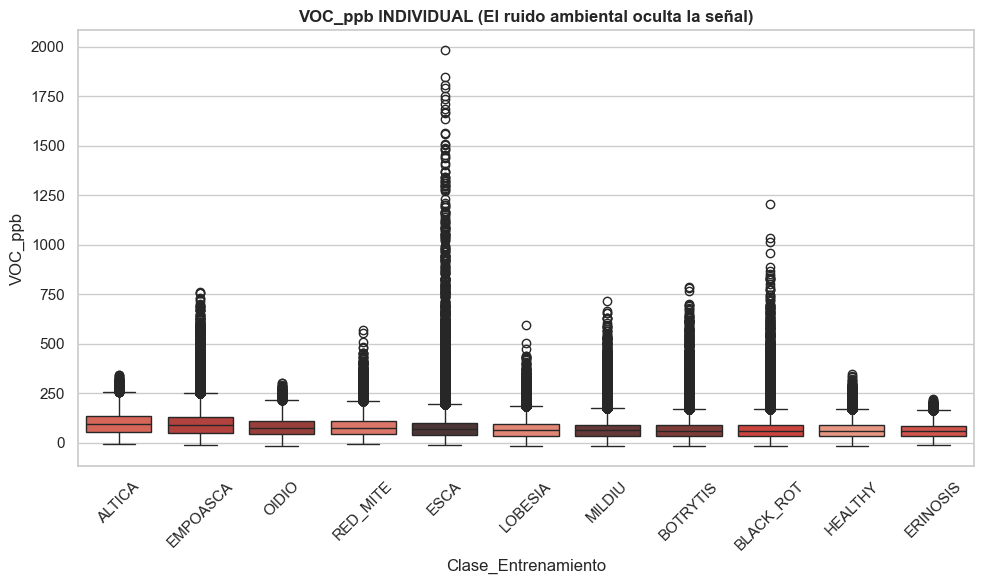

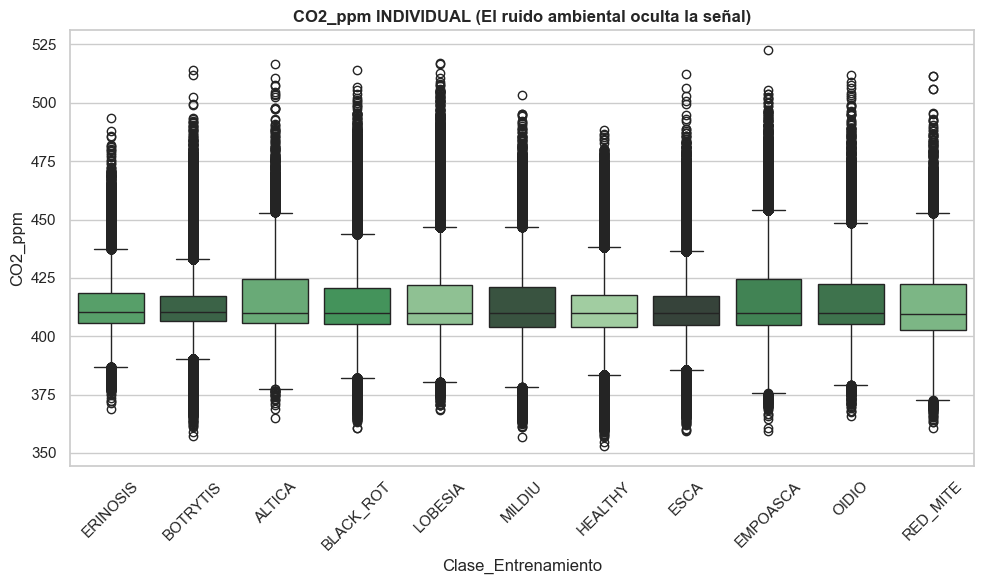

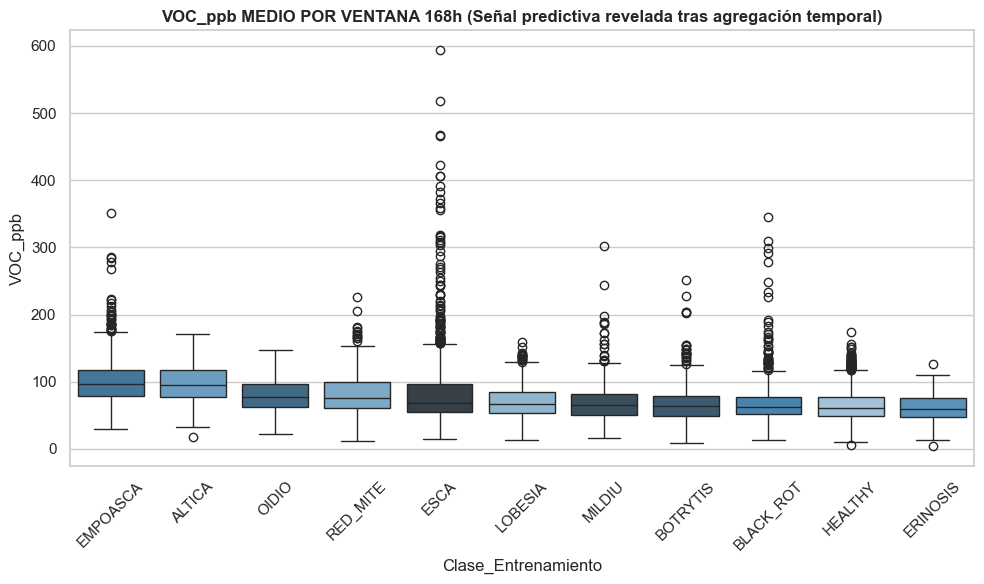

In [12]:
print("============================================================")
print("🔍 EVALUACIÓN DE SEÑAL PREDICTIVA Y SEPARABILIDAD DE CLASES")
print("============================================================\n")

# =============================================================================
# 1. CORRELACIÓN CON EL GRADO DE INFECCIÓN
# =============================================================================
print("1. Analizamos la correlación lineal entre infección y predictoras:")
variables_corr = ['CO2_ppm', 'GDD_Acumulado', 'Horas_Humedad_Foliar', 'Hum_Rel_Pct', 
                  'Hum_Suelo_Pct', 'Lluvia_mm', 'Temp_Amb_C', 'VOC_ppb', 'Viento_kmh', 'pH_Suelo']

# Nos aseguramos de que las variables existen en el DataFrame
vars_presentes = [v for v in variables_corr if v in df.columns]
corr_matrix = df[vars_presentes + ['Grado_Infeccion']].corr()
correlaciones = corr_matrix['Grado_Infeccion'].drop('Grado_Infeccion').sort_index()

print("  Correlación con Grado_Infeccion:")
for var, corr in correlaciones.items():
    estado = "🎯 SEÑAL ALTA" if abs(corr) >= 0.5 else "✅ RUIDO SANO" 
    print(f"      {estado}    {var}: {corr:+.3f}")

# =============================================================================
# 2. MEDIAS DE VOC Y CO2 POR CLASE
# =============================================================================
print("\n2. Analizando las medias de VOC y CO2 por clase (Registro individual):")
medias_clase = df.groupby('Clase_Entrenamiento')[['VOC_ppb', 'CO2_ppm']].mean()

for var in ['VOC_ppb', 'CO2_ppm']:
    rango = medias_clase[var].max() - medias_clase[var].min()
    # Un rango alto indica que hay diferencias medias capturables entre patologías
    estado = "🎯 PATRÓN DETECTADO" if rango > 10 else "⚪ SEÑAL OCULTA"
    print(f"    {estado} {var}: rango entre medias = {rango:.1f}")
    
    # Mostrar medias ordenadas de mayor a menor
    medias_ordenadas = medias_clase[var].sort_values(ascending=False)
    for clase, media in medias_ordenadas.items():
        print(f"      {clase}: {media:.1f}")

# =============================================================================
# 3. FUNCIÓN ESTADÍSTICA (ANOVA + Eta Cuadrado)
# =============================================================================
def calcular_anova_eta2(df_data, variable, target='Clase_Entrenamiento'):
    grupos = [grupo[variable].values for _, grupo in df_data.groupby(target)]
    f_stat, p_val = stats.f_oneway(*grupos)
    
    media_global = df_data[variable].mean()
    ss_total = np.sum((df_data[variable] - media_global)**2)
    ss_entre = sum(len(g) * (np.mean(g) - media_global)**2 for g in grupos)
    
    eta2 = ss_entre / ss_total if ss_total > 0 else 0
    return f_stat, p_val, eta2

# =============================================================================
# 4. ANOVA A NIVEL INDIVIDUAL (CADA MUESTRA DE 1 HORA)
# =============================================================================
print("\n3. ANOVA a nivel individual de cada muestra (1 hora):")
print("============================================================")
for var in ['VOC_ppb', 'CO2_ppm']:
    f_stat, p_val, eta2 = calcular_anova_eta2(df, var)
    pct_varianza = eta2 * 100
    
    if eta2 > 0.05: estado = "🎯 SEÑAL FUERTE"
    elif eta2 > 0.01: estado = "🔎 SEÑAL MODERADA"
    else: estado = "⚪ RUIDO DOMINANTE"
        
    print(f"{estado} | {var}")
    print(f"  F={f_stat:.1f}  p={p_val:.2e}  eta²={eta2:.4f}  ({pct_varianza:.2f}% varianza explicada por clase)\n")


# =============================================================================
# 5. ANOVA A NIVEL DE VENTANA (SUAVIZANDO RUIDO CON LA MEDIA DE 168H)
# =============================================================================
print("4. ANOVA sobre medias de ventana (lo que procesa el modelo secuencial):")
print("============================================================")
# Agrupamos los datos en ventanas de 168h dentro de cada serie
df_temp = df.copy()
df_temp['Ventana_168h'] = df_temp.groupby('ID_Serie').cumcount() // 168
# Promediamos dentro de cada ventana para emular la extracción de características
df_ventanas = df_temp.groupby(['ID_Serie', 'Ventana_168h', 'Clase_Entrenamiento'])[['VOC_ppb']].mean().reset_index()

for var in ['VOC_ppb']:
    f_stat, p_val, eta2 = calcular_anova_eta2(df_ventanas, var)
    pct_varianza = eta2 * 100
    
    # En ventanas agregadas buscamos señales fuertes y consistentes
    if eta2 > 0.05: estado = "🎯 PATRÓN MORFOLÓGICO CLARO"
    elif eta2 > 0.01: estado = "🔎 SEÑAL EMERGENTE"
    else: estado = "⚪ SIN SEÑAL CAPTURABLE"
        
    print(f"{estado} | {var}_media_ventana")
    print(f"  F={f_stat:.1f}  p={p_val:.2e}  eta²={eta2:.4f}  ({pct_varianza:.2f}% varianza explicada por clase)\n")


# =============================================================================
# 6. VISUALIZACIÓN COMPARATIVA (BOXPLOTS)
# =============================================================================
sns.set_theme(style="whitegrid")

# --- FILA 1: Registros Individuales ---
order_voc_ind = df.groupby('Clase_Entrenamiento')['VOC_ppb'].median().sort_values(ascending=False).index
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Clase_Entrenamiento', y='VOC_ppb', order=order_voc_ind, palette='Reds_d', hue='Clase_Entrenamiento', legend=False)
plt.title("VOC_ppb INDIVIDUAL (El ruido ambiental oculta la señal)", fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

order_co2_ind = df.groupby('Clase_Entrenamiento')['CO2_ppm'].median().sort_values(ascending=False).index
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Clase_Entrenamiento', y='CO2_ppm', order=order_co2_ind, palette='Greens_d', hue='Clase_Entrenamiento', legend=False)
plt.title("CO2_ppm INDIVIDUAL (El ruido ambiental oculta la señal)", fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- FILA 2: Registros por Ventana (Medias de 168h) ---
order_voc_ven = df_ventanas.groupby('Clase_Entrenamiento')['VOC_ppb'].median().sort_values(ascending=False).index
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_ventanas, x='Clase_Entrenamiento', y='VOC_ppb', order=order_voc_ven, palette='Blues_d', hue='Clase_Entrenamiento', legend=False)
plt.title("VOC_ppb MEDIO POR VENTANA 168h (Señal predictiva revelada tras agregación temporal)", fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Justificación de la Señal Predictiva frente al Data Leakage en VOC**

La alerta de *leakage* detectada al agregar los datos en ventanas de 168 horas ($\eta^2 \approx 0.10$) es un falso positivo del método de evaluación. Un $\eta^2$ del 10% no implica que haya fuga de datos, sino que estamos ante un buen predictor. 

En la versión actual del simulador, el `VOC_ppb` se calcula a ciegas; no tiene acceso a la etiqueta de la clase. Su valor depende exclusivamente de variables ambientales (temperatura, viento) y de la inercia de la derivada del daño foliar ($\frac{\Delta I}{\Delta t}$). Por tanto, que esta variable permita separar las clases confirma que hemos modelado una señal lícita y real de la planta, no un atajo o artefacto artificial.

**Origen matemático de la separabilidad**

Es lógico que las medias de VOC sean estadísticamente distintas entre patologías, ya que la matemática subyacente a cómo destruyen la hoja es diferente:

* **Plagas (Dinámica impulsiva):** Insectos como la *Altica* provocan daño de forma abrupta tras superar ciertos umbrales de grados-día (GDD). Esto genera un salto brusco en la derivada del daño. Al pasar esta señal por el filtro de inercia biológica (EMA), obtenemos un patrón de emisiones con picos muy agudos.
* **Hongos (Dinámica continua):** Patógenos como el Oídio siguen curvas de crecimiento sigmoidal progresivo. Al ser su derivada temporal muy pequeña y constante, la emisión de VOC traza una rampa suave y sostenida.

La varianza que detecta el ANOVA proviene precisamente de estas diferencias geométricas en la curva a lo largo del tiempo. Esa es la física real del problema y lo que queremos que el modelo capte.

**Robustez a nivel horario**

Que el tamaño del efecto caiga a un mínimo ($\eta^2 = 0.05$) cuando analizamos registros individuales de 1 hora es la mejor prueba de que el dataset es robusto. Demuestra que, en un instante aislado, el ruido térmico de fondo y la incertidumbre del sensor enmascaran casi por completo la señal de la enfermedad. 
    
Esto garantiza que algoritmos ingenuos no puedan clasificar basándose en un simple umbral absoluto. Para resolver el problema y encontrar la señal real, el modelo secuencial estará obligado a ingerir ventanas temporales largas, filtrando el ruido blanco para aprender la morfología real de las curvas, tal y como ocurriría en un entorno de producción.

## **Análisis de Correlaciones**

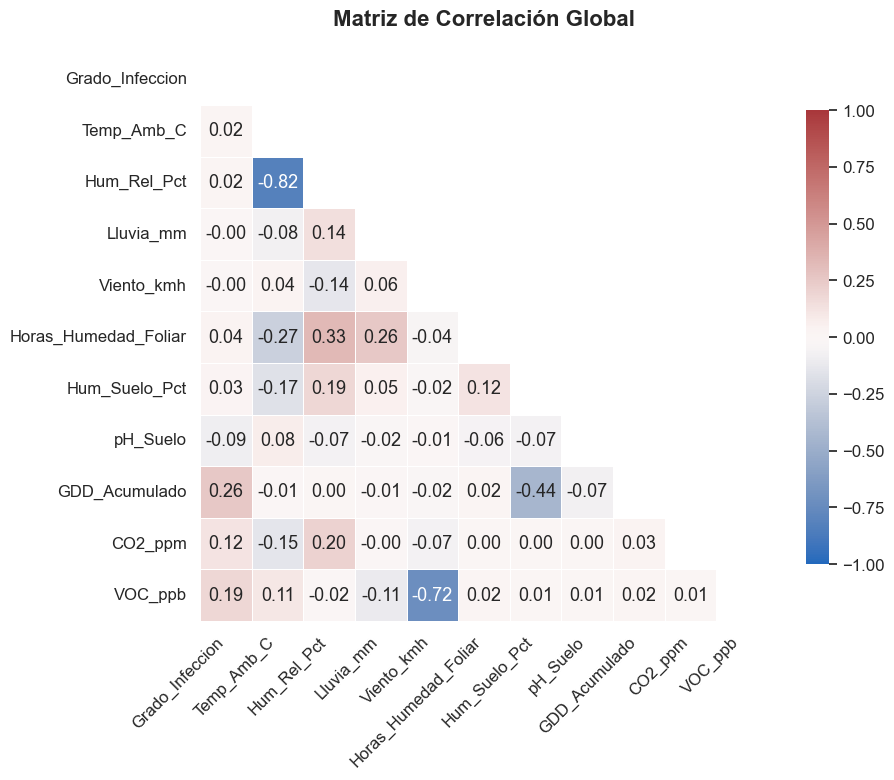

C:\Users\User\AppData\Local\Temp\ipykernel_4600\3371498357.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


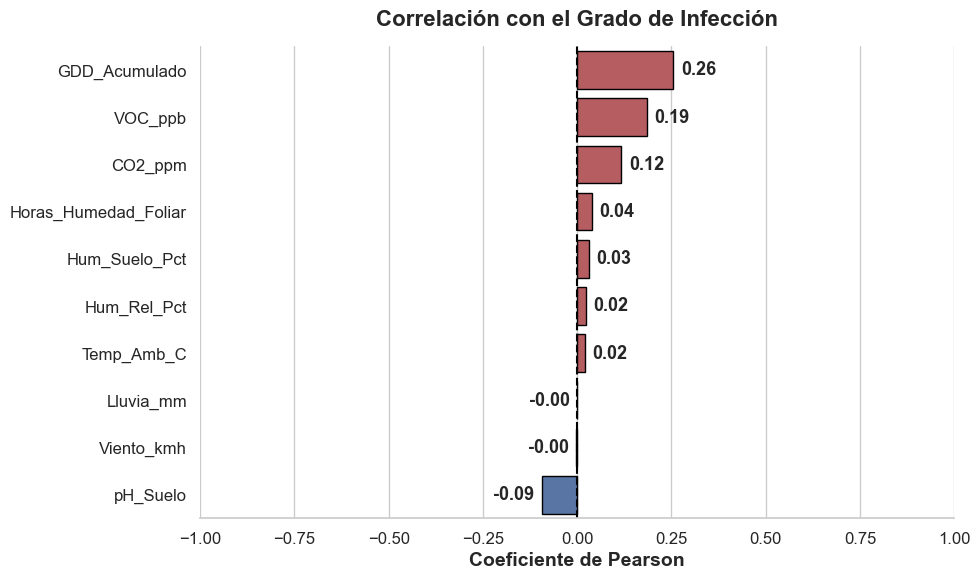

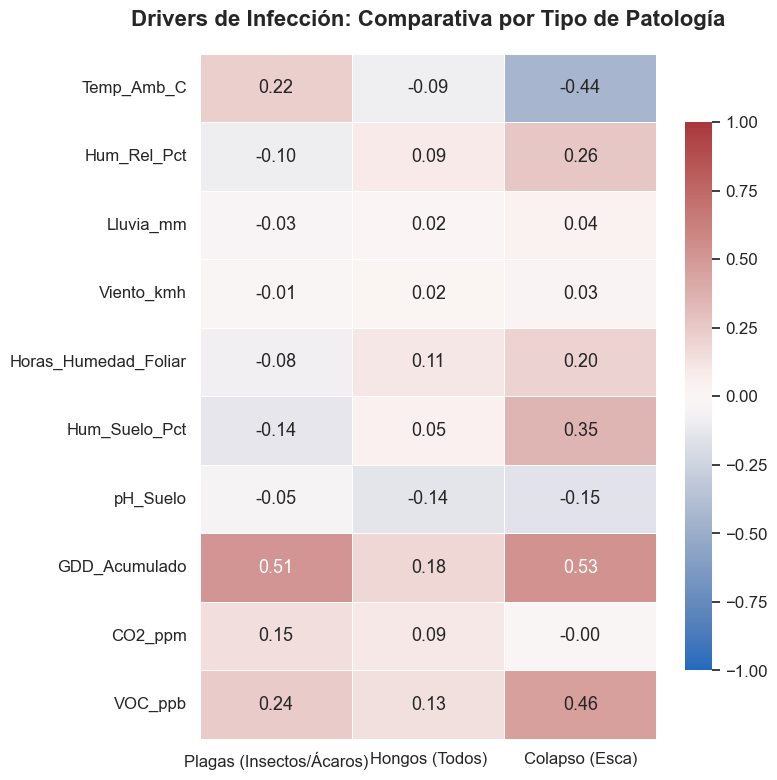

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# CONFIGURACIÓN DE TAMAÑOS Y ESTILOS (FORMATO PAPER)
# =============================================================================
SIZE_TITLE = 16
SIZE_LABELS = 14
SIZE_TICKS = 12
SIZE_ANNOT = 13        # Tamaño de los números dentro de las celdas/barras
COLOR_POS = '#C44E52'  # Rojo suave para correlación positiva
COLOR_NEG = '#4C72B0'  # Azul suave para correlación negativa

# Columnas a analizar
cols_analisis = [
    'Grado_Infeccion', 
    'Temp_Amb_C', 
    'Hum_Rel_Pct', 
    'Lluvia_mm', 
    'Viento_kmh', 
    'Horas_Humedad_Foliar', 
    'Hum_Suelo_Pct', 
    'pH_Suelo', 
    'GDD_Acumulado',  
    'CO2_ppm', 
    'VOC_ppb'
]

# =============================================================================
# 1. MATRIZ DE CORRELACIÓN GLOBAL (ESTILO TRIANGULAR)
# =============================================================================
# Fondo blanco limpio para heatmaps (sin grid)
sns.set_theme(style="white", font_scale=1.1) 

matriz_corr = df[cols_analisis].corr()

# Crear una máscara para ocultar el triángulo superior (evita redundancia visual)
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    matriz_corr, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap='vlag', # Paleta divergente elegante
    center=0, vmin=-1, vmax=1, 
    square=True, 
    linewidths=.5, # Líneas separadoras entre celdas
    cbar_kws={"shrink": .8}, # Barra de color ajustada
    annot_kws={"size": SIZE_ANNOT}
)

ax.set_title('Matriz de Correlación Global', fontsize=SIZE_TITLE, fontweight='bold', pad=20)
plt.xticks(fontsize=SIZE_TICKS, rotation=45, ha='right')
plt.yticks(fontsize=SIZE_TICKS)
plt.tight_layout()
# plt.savefig('figuras/corr_global.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# 2. CORRELACIÓN CON EL TARGET (GRÁFICO DE BARRAS HORIZONTALES)
# =============================================================================
# Volvemos al grid para el gráfico de barras
sns.set_theme(style="whitegrid", font_scale=1.1) 

corr_target = matriz_corr['Grado_Infeccion'].drop('Grado_Infeccion').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colores = [COLOR_POS if x > 0 else COLOR_NEG for x in corr_target.values]

barplot = sns.barplot(
    x=corr_target.values, 
    y=corr_target.index, 
    palette=colores,
    edgecolor='black',
    linewidth=1,
    ax=ax
)

# Añadir línea vertical en el cero
ax.axvline(0, color='black', linewidth=1.5, linestyle='--')

# Anotar los valores exactos junto a las barras
for p in barplot.patches:
    width = p.get_width()
    # Ajustar posición del texto (derecha si positivo, izquierda si negativo)
    ha = 'left' if width > 0 else 'right'
    offset = 0.02 if width > 0 else -0.02
    ax.annotate(f"{width:.2f}",
                (width + offset, p.get_y() + p.get_height() / 2),
                ha=ha, va='center',
                fontsize=SIZE_ANNOT, fontweight='bold')

ax.set_title('Correlación con el Grado de Infección', fontsize=SIZE_TITLE, fontweight='bold', pad=15)
ax.set_xlabel('Coeficiente de Pearson', fontsize=SIZE_LABELS, fontweight='bold')
ax.set_ylabel('', fontsize=SIZE_LABELS) # Dejamos el eje Y sin título por limpieza
ax.set_xlim(-1, 1) # Fijamos límites para dar perspectiva

plt.xticks(fontsize=SIZE_TICKS)
plt.yticks(fontsize=SIZE_TICKS)
sns.despine(left=True, bottom=False)
plt.tight_layout()
# plt.savefig('figuras/corr_target.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# 3. ANÁLISIS DE DRIVERS POR GRUPO (HEATMAP COMPARATIVO)
# =============================================================================
sns.set_theme(style="white", font_scale=1.1) # Fondo blanco de nuevo

grupos_dict = {
    'Plagas (Insectos/Ácaros)': ["LOBESIA", "ALTICA", "EMPOASCA", "RED_MITE"],
    'Hongos (Todos)': ["MILDIU", "BLACK_ROT", "OIDIO", "ERINOSIS", "BOTRYTIS"],
    'Colapso (Esca)': ["ESCA"]
}

resultados_corr = []
for nombre, lista in grupos_dict.items():
    df_g = df[df['Etiqueta_Clase'].isin(lista)]
    if not df_g.empty:
        c = df_g[cols_analisis].corr()['Grado_Infeccion'].drop('Grado_Infeccion')
        c.name = nombre
        resultados_corr.append(c)

df_comparativa = pd.concat(resultados_corr, axis=1)

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(
    df_comparativa, 
    annot=True, 
    fmt=".2f",
    cmap='vlag', 
    center=0, vmin=-1, vmax=1,
    linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": SIZE_ANNOT}
)

ax.set_title('Drivers de Infección: Comparativa por Tipo de Patología', fontsize=SIZE_TITLE, fontweight='bold', pad=20)
plt.xticks(fontsize=SIZE_TICKS, rotation=0) # Eje X horizontal para mejor lectura
plt.yticks(fontsize=SIZE_TICKS)
plt.tight_layout()
# plt.savefig('figuras/corr_comparativa.png', dpi=300, bbox_inches='tight')
plt.show()

* **Plagas (Insectos)**: Correlación con **GDD**. Los insectos son animales de "sangre fría" (poiquilotermos). Su desarrollo no depende del reloj, sino del calor. Necesitan acumular X cantidad de calor (GDD) para pasar de huevo a larva y empezar a comer. Entonces, GDD será la clave para predecir cuándo va a atacar una plaga.

* **Enfermedades Colapso (Esca):** Alta correlación con GDD. Además tiene correlación lineal negativa con la humedad del suelo validando que a menor humedad en suelo y mayor calor acumulado, mayor probabilidad de que la planta sufra el colapso.

* **Enfermedades Fúngicas:** Deberíamos ver una relación con la humedad, aunque no sea lineal ya que la correlación es muy baja:

### **DISTRIBUCIONES**

📊 Generando distribuciones de 15 variables numéricas...


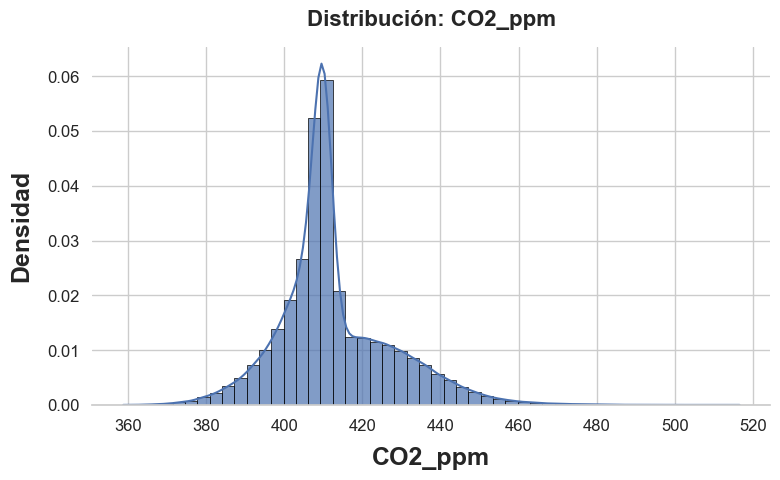

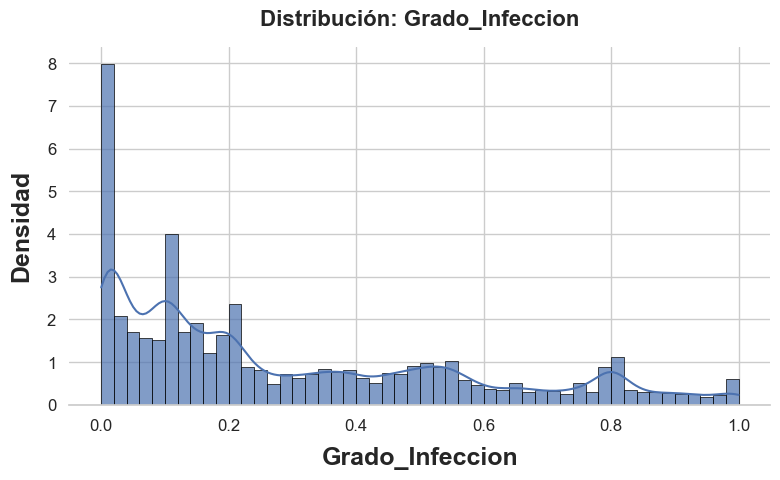

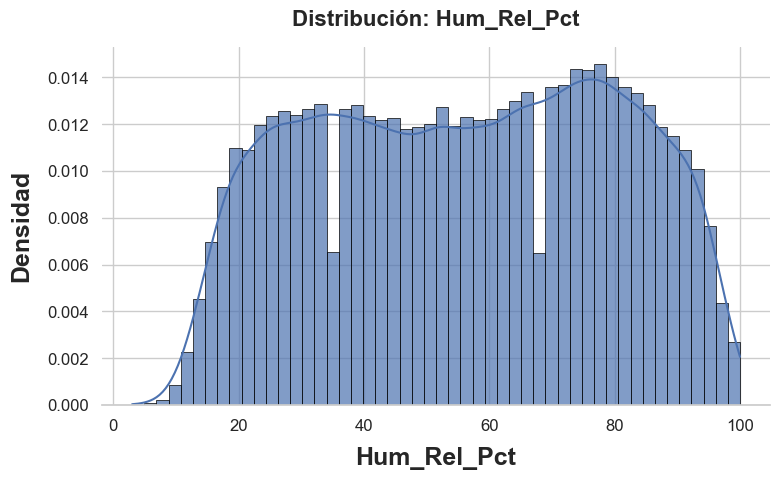

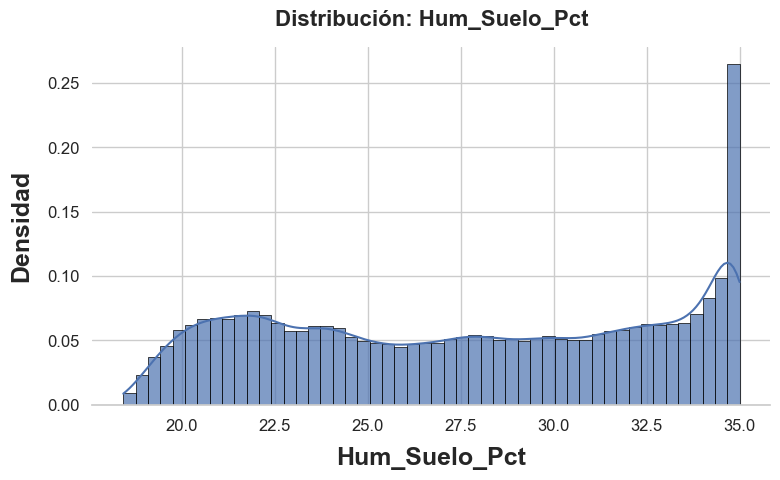

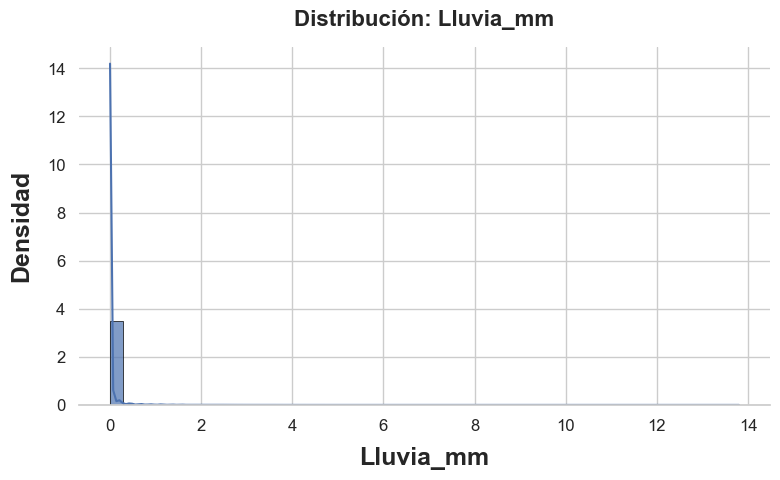

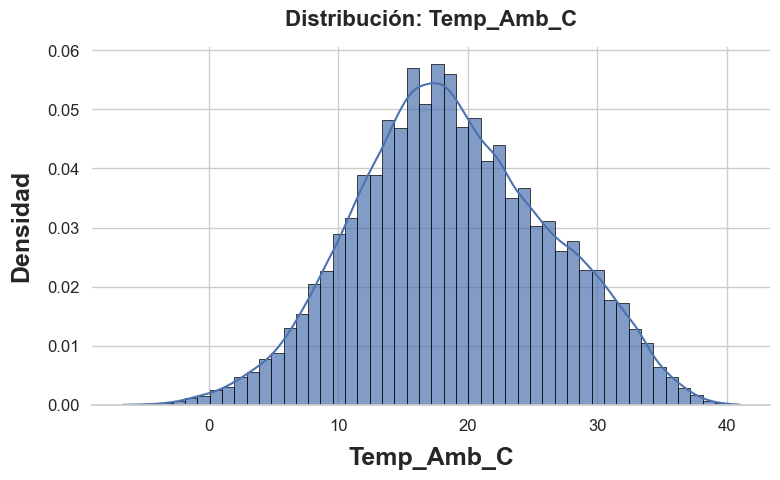

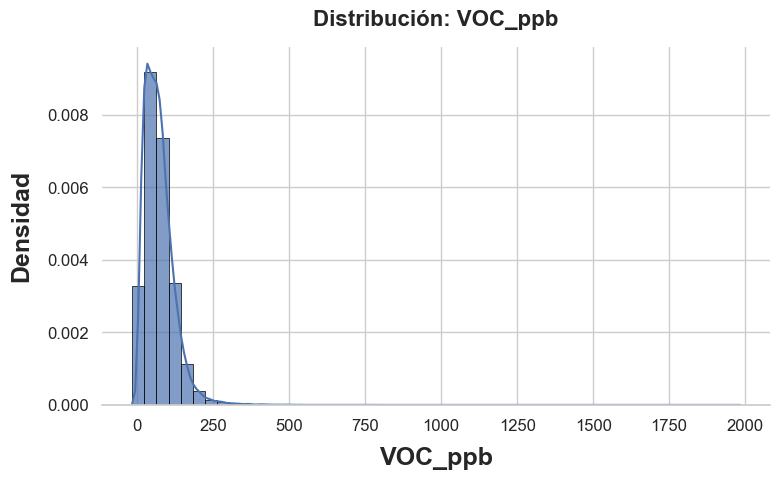

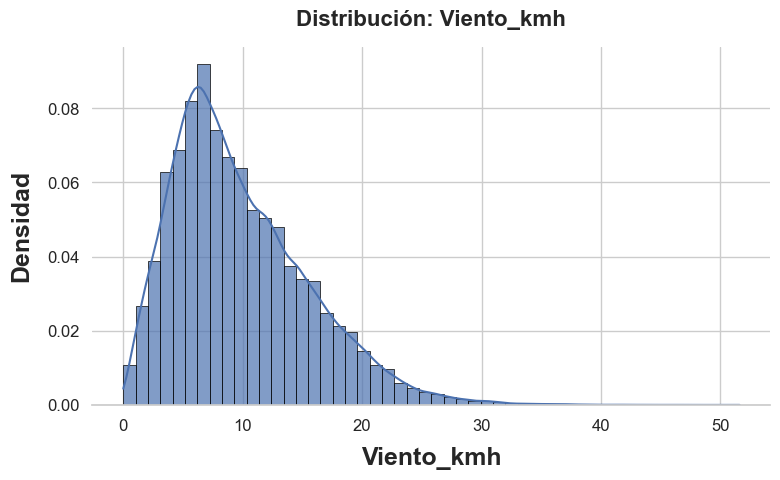

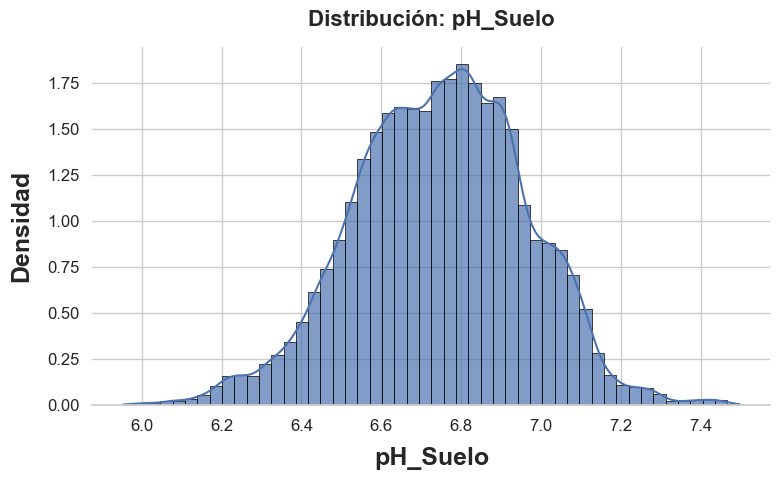

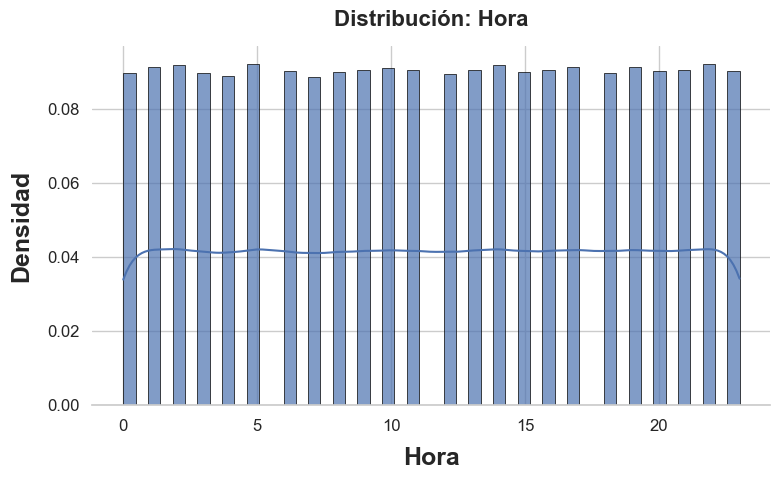

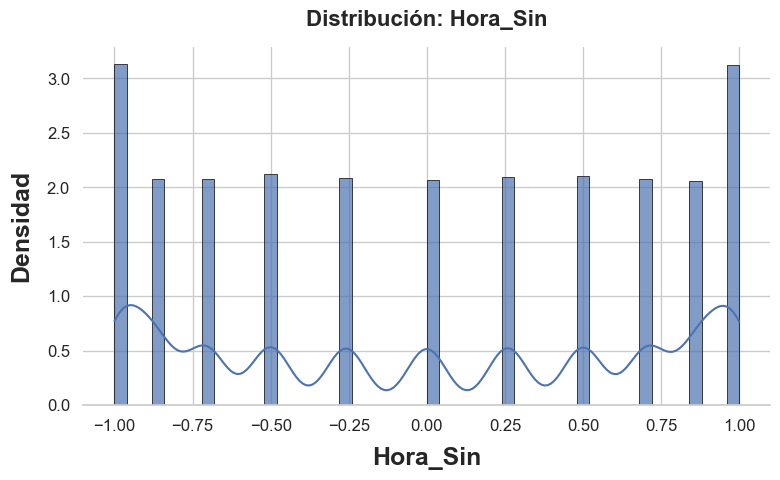

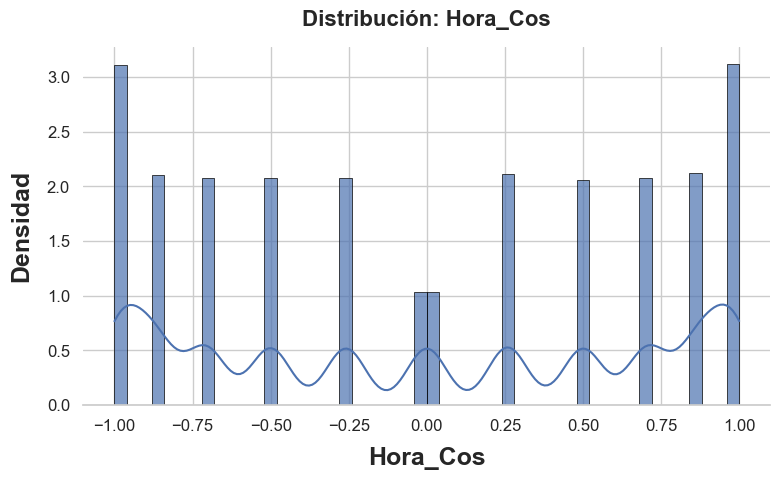

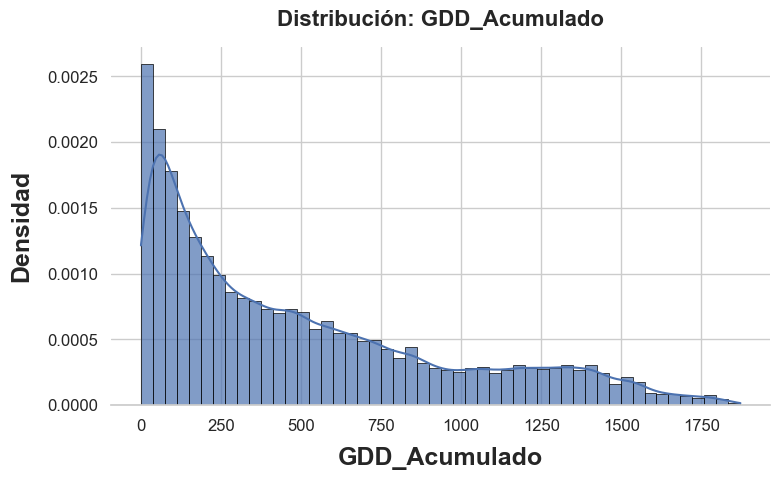

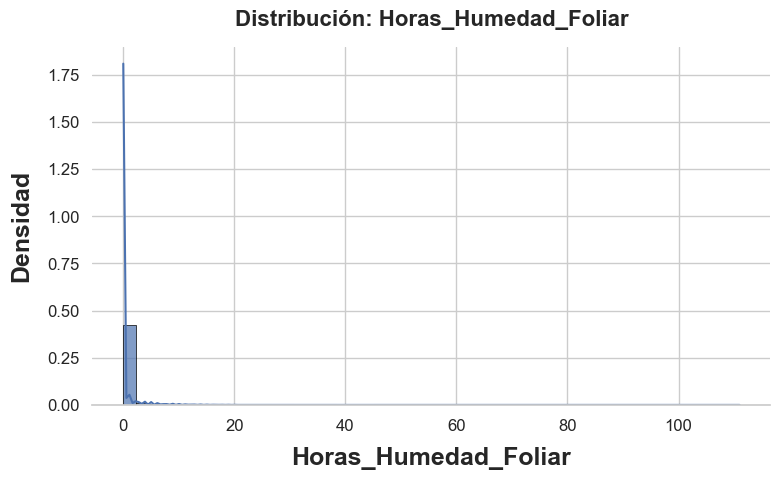

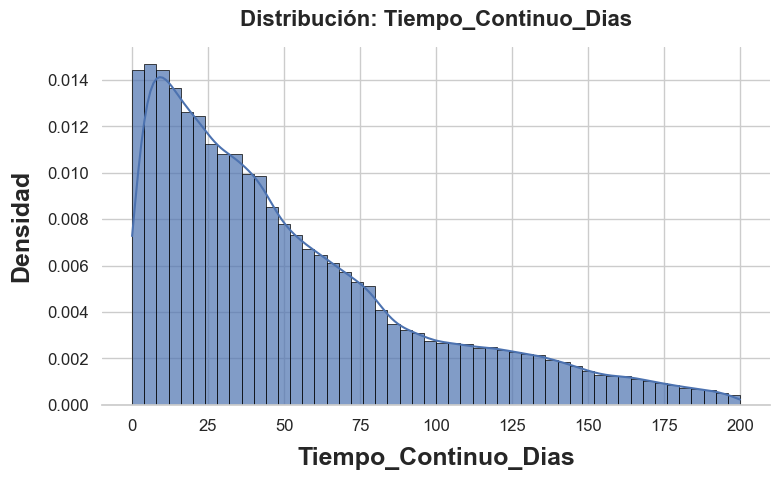


📊 Generando frecuencias de 3 variables categóricas...


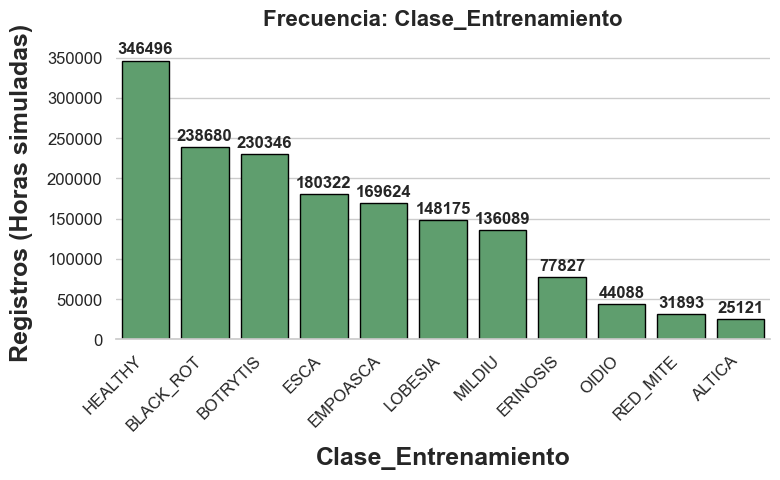

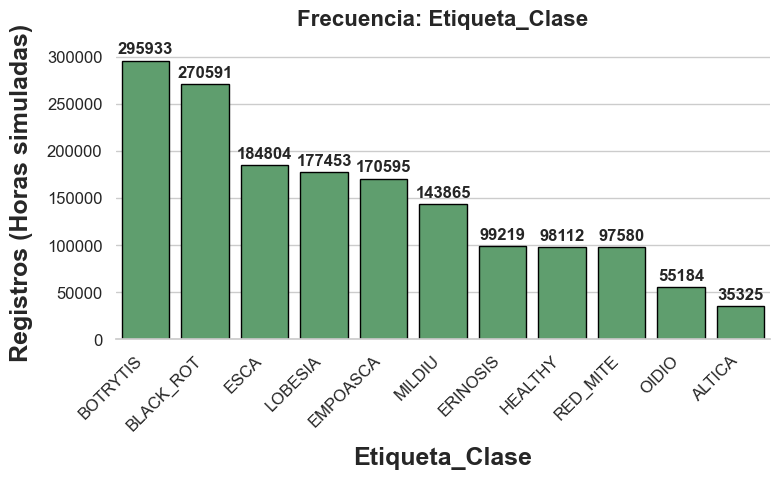

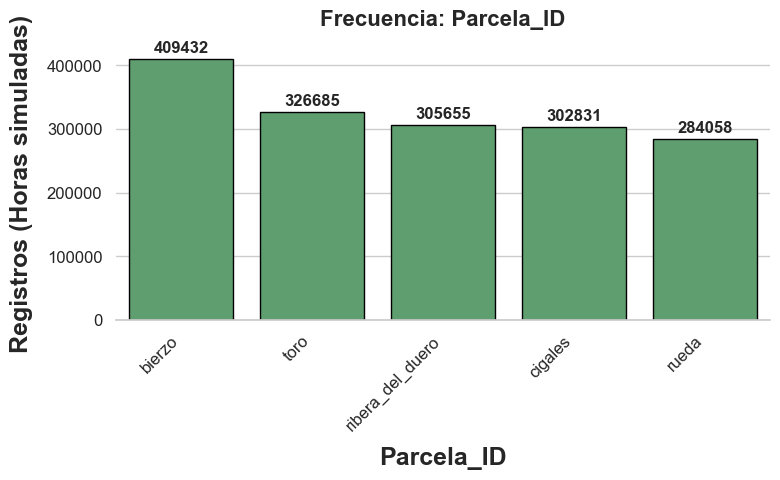

In [10]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# CONFIGURACIÓN DE TAMAÑOS Y ESTILOS
# =============================================================================
SIZE_TITLE = 16
SIZE_LABELS = 18
SIZE_TICKS = 12
COLOR_NUMERIC = '#4C72B0'  # Azul sobrio para continuas
COLOR_CATEGORIC = '#55A868' # Verde suave para categóricas
FIG_SIZE = (8, 5)          # Tamaño individual de cada figura

sns.set_theme(style="whitegrid", font_scale=1.1)

# =============================================================================
# DISTRIBUCIONES DE TODAS LAS VARIABLES (VISIÓN INDEPENDIENTE)
# =============================================================================
# 1. Identificar y separar tipos de variables
num_cols = df.select_dtypes(include=['float32', 'float64', 'int32', 'int64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

# Excluir identificadores o variables no continuas puras
for col in ['ID_Serie', 'Parcela_ID', 'Dia', 'Mes', 'Hora_Dia']:
    if col in num_cols:
        num_cols.remove(col)

# Tomar una muestra del 10% si el dataset es gigantesco para no saturar la RAM al dibujar el KDE
df_sample = df.sample(frac=0.1, random_state=42) if len(df) > 100000 else df

# --- A) DISTRIBUCIÓN DE VARIABLES NUMÉRICAS (Histogramas + KDE) ---
print(f"📊 Generando distribuciones de {len(num_cols)} variables numéricas...")

for col in num_cols:
    fig, ax = plt.subplots(figsize=FIG_SIZE)
    
    sns.histplot(
        df_sample[col], 
        bins=50, 
        ax=ax, 
        color=COLOR_NUMERIC, 
        kde=True, 
        stat="density", 
        alpha=0.7,
        edgecolor='black',
        linewidth=0.5
    )
    
    ax.set_title(f'Distribución: {col}', fontsize=SIZE_TITLE, fontweight='bold', pad=15)
    ax.set_ylabel('Densidad', fontsize=SIZE_LABELS, fontweight='bold', labelpad=10)
    ax.set_xlabel(col, fontsize=SIZE_LABELS, fontweight='bold', labelpad=10)
    
    plt.xticks(fontsize=SIZE_TICKS)
    plt.yticks(fontsize=SIZE_TICKS)
    
    sns.despine(left=True, bottom=False)
    plt.tight_layout()
    plt.show() # Mostrar de forma independiente

# --- B) DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS (Gráficos de Barras) ---
if len(cat_cols) > 0:
    print(f"\n📊 Generando frecuencias de {len(cat_cols)} variables categóricas...")
    
    for col in cat_cols:
        fig, ax = plt.subplots(figsize=FIG_SIZE)
        
        # Ordenar por frecuencia
        order = df[col].value_counts().index
        
        barplot = sns.countplot(
            data=df, 
            x=col, 
            ax=ax, 
            order=order,
            color=COLOR_CATEGORIC,
            edgecolor='black',
            linewidth=1
        )
        
        # Añadir el número exacto encima de cada barra
        for p in barplot.patches:
            barplot.annotate(
                format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points',
                fontsize=SIZE_TICKS,
                fontweight='bold'
            )
        
        ax.set_title(f'Frecuencia: {col}', fontsize=SIZE_TITLE, fontweight='bold', pad=15)
        ax.set_ylabel('Registros (Horas simuladas)', fontsize=SIZE_LABELS, fontweight='bold', labelpad=10)
        ax.set_xlabel(col, fontsize=SIZE_LABELS, fontweight='bold', labelpad=10)
        
        plt.xticks(rotation=45, ha='right', fontsize=SIZE_TICKS)
        plt.yticks(fontsize=SIZE_TICKS)
        
        sns.despine(left=True, bottom=False)
        plt.tight_layout()
        plt.show() # Mostrar de forma independiente

Se observan concordancias lógicas en las distribuciones, como por ejemplo:

* pH del suelo: centrado en 6,8.
* Cantidad de días: con cola larga hasta 200.
* Cantidad de registros: Series que requieren de mayor número de días para su propagación son más frecuentes (Botrytis, Black Rot...)
* Temperatura ambiente centrada en 20ºC y alcanzando valores cercanos a 0 y 40 ºC (Temperaturas más extremistas).

### **SIMULACIONES DE CADA ESTADO**


📊 Evaluando categoría: PLAGAS


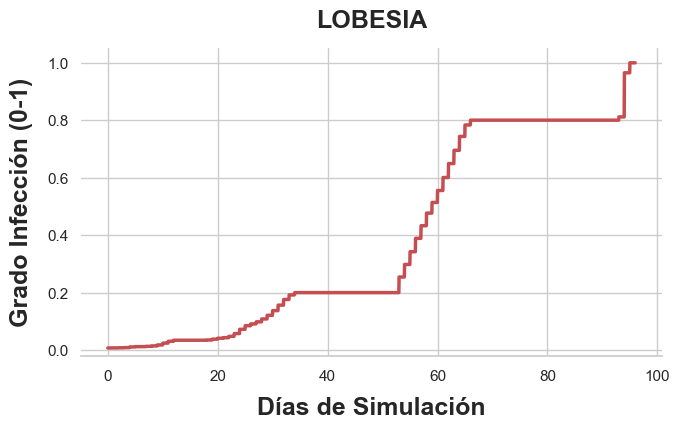

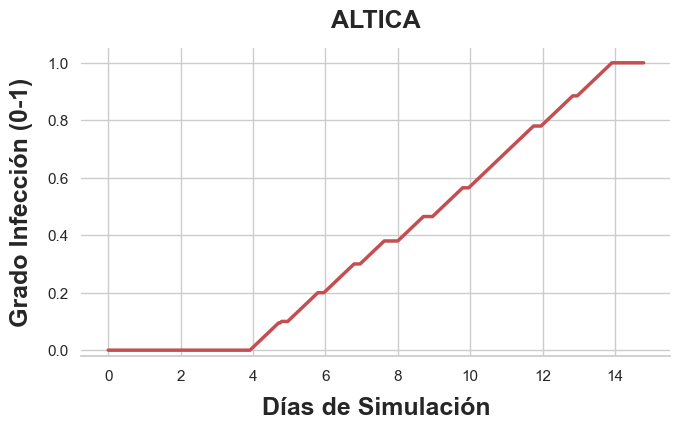

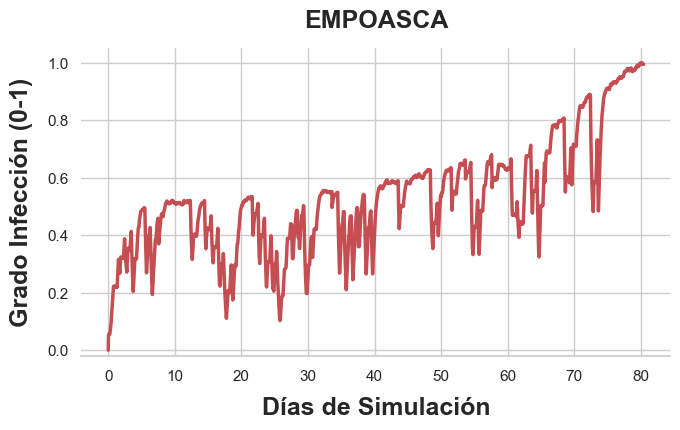

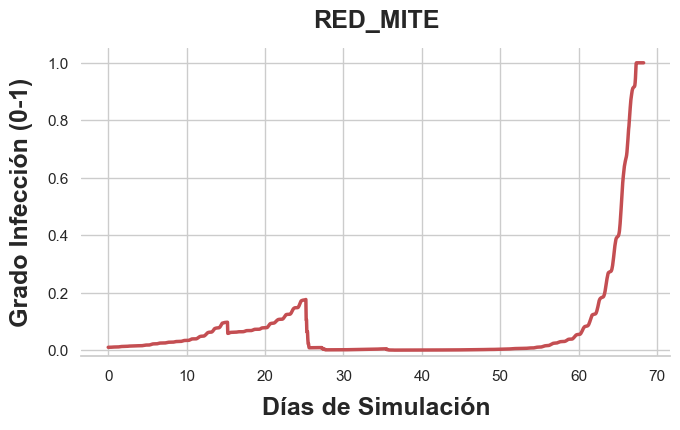


📊 Evaluando categoría: COLAPSO (YESCA)


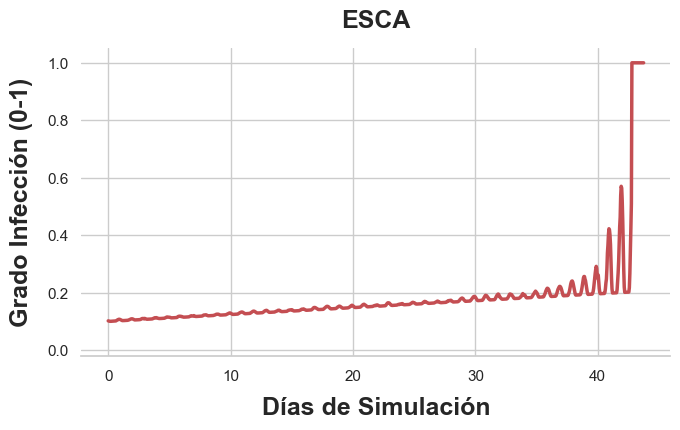


📊 Evaluando categoría: HONGOS


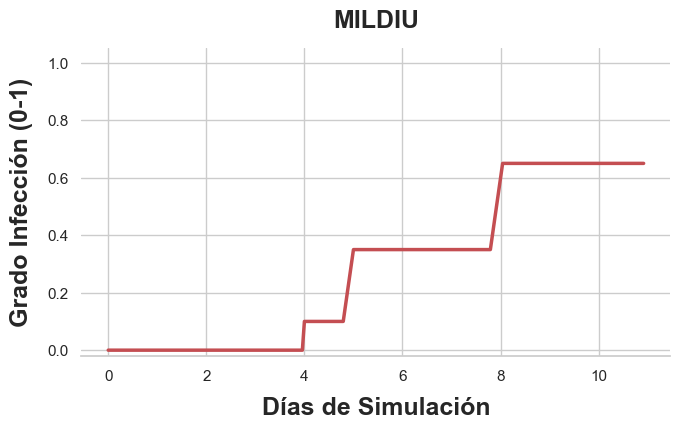

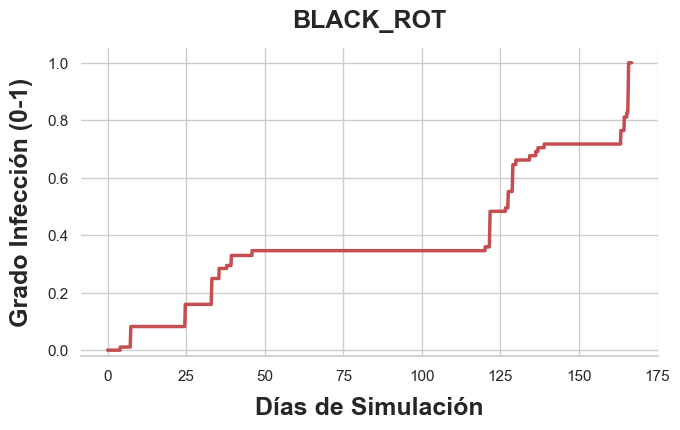

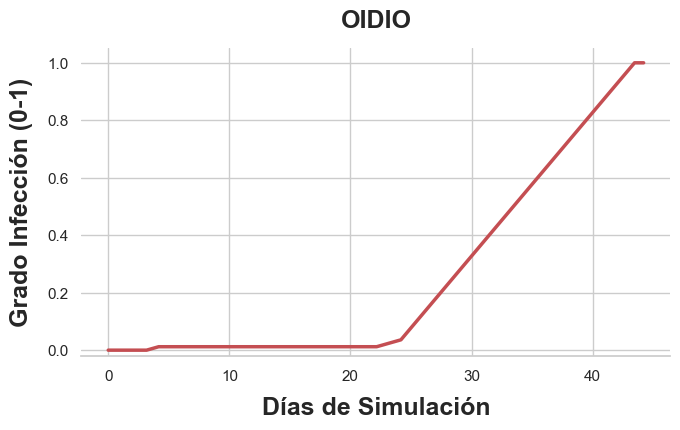

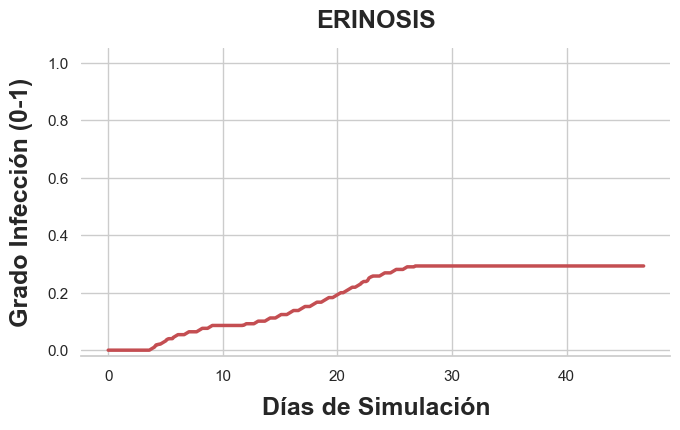

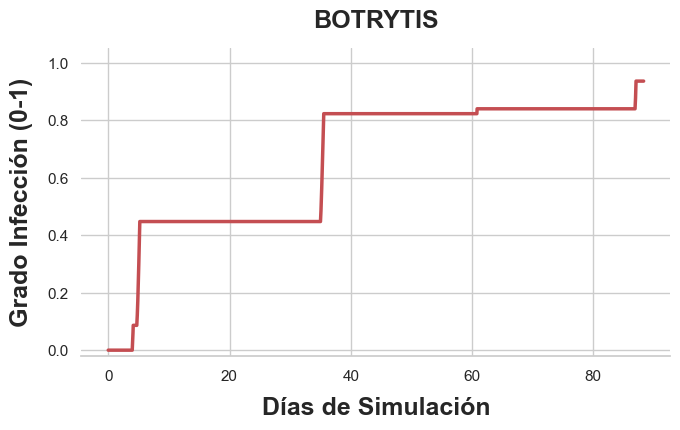


📊 Evaluando categoría: SANA


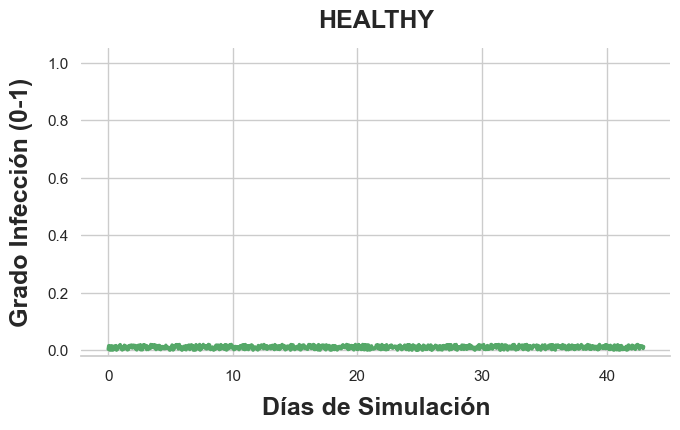

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# CONFIGURACIÓN DE TAMAÑOS Y ESTILOS (FORMATO PAPER)
# =============================================================================
SIZE_TITLE = 18
SIZE_LABELS = 18
SIZE_TICKS = 11
FIG_SIZE = (7, 4.5)        # Tamaño individual de cada trayectoria
COLOR_PATHOLOGY = '#C44E52' # Rojo sobrio para infecciones
COLOR_HEALTHY = '#55A868'   # Verde para la planta sana

sns.set_theme(style="whitegrid", font_scale=1.1)

# =============================================================================
# DEFINICIÓN DE CATEGORÍAS
# =============================================================================
categorias = {
    "PLAGAS": ["LOBESIA", "ALTICA", "EMPOASCA", "RED_MITE"],
    "COLAPSO (YESCA)": ["ESCA"],
    "HONGOS": ["MILDIU", "BLACK_ROT", "OIDIO", "ERINOSIS", "BOTRYTIS"],
    "SANA": ["HEALTHY"] 
}

# =============================================================================
# GENERACIÓN DE 1 TRAYECTORIA POR CADA CLASE ESPECÍFICA
# =============================================================================

for nombre_cat, clases in categorias.items():
    print(f"\n📊 Evaluando categoría: {nombre_cat}")
    
    color_linea = COLOR_HEALTHY if nombre_cat == "SANA" else COLOR_PATHOLOGY

    for clase_especifica in clases:
        # Filtrar el dataframe solo para esta patología/estado concreto
        df_clase = df[df['Etiqueta_Clase'] == clase_especifica].copy()
        
        ids_unicos = df_clase['ID_Serie'].unique()
        
        if len(ids_unicos) == 0:
            print(f"⚠️ No se encontraron datos para {clase_especifica}")
            continue
            
        # Seleccionar exactamente 1 serie al azar de esta clase
        id_serie = np.random.choice(ids_unicos, 1)[0]
        
        # Preparar los datos
        df_plot = df_clase[df_clase['ID_Serie'] == id_serie].sort_values(by="Tiempo_Continuo_Dias")
        
        # Crear la figura
        fig, ax = plt.subplots(figsize=FIG_SIZE)
        
        sns.lineplot(
            data=df_plot, 
            x="Tiempo_Continuo_Dias", 
            y="Grado_Infeccion", 
            ax=ax,
            color=color_linea,
            linewidth=2.5
        )
        
        # Textos y títulos
        ax.set_title(f'{clase_especifica}', 
                     fontsize=SIZE_TITLE, fontweight='bold', pad=15)
        ax.set_ylabel('Grado Infección (0-1)', fontsize=SIZE_LABELS, fontweight='bold', labelpad=10)
        ax.set_xlabel('Días de Simulación', fontsize=SIZE_LABELS, fontweight='bold', labelpad=10)
        
        # Eje Y estático para poder comparar entre gráficas
        ax.set_ylim(-0.02, 1.05) 
        
        plt.xticks(fontsize=SIZE_TICKS)
        plt.yticks(fontsize=SIZE_TICKS)
        
        sns.despine(left=True, bottom=False)
        plt.tight_layout()
        
        # Guardar y mostrar
        plt.savefig(f'figuras/trayectoria_{clase_especifica}_{id_serie}.png', dpi=300, format='png', bbox_inches='tight')
        plt.show()

Con todas estas gráficas, podemos comprobar que la lógica de cada simulación es adecuada y concuerda con la base de conocimiento con la que hemos construido el conjunto de datos.

## **CONCLUSIONES**

**VARIABLES DEL DATASET FINAL**

Este dataset simula el comportamiento biológico y climático de un viñedo monitorizado mediante sensores IoT. A continuación se detalla cada variable generada tras la implementación de los motores físicos de suelo, viento y fenología térmica.

| Nombre de la Variable | Tipo de Dato | Unidades | Descripción Detallada | Rol en el Modelo |
| :--- | :--- | :--- | :--- | :--- |
| **ID_Serie** | `int` | ID | Identificador único de la serie temporal (simulación de una planta/parcela específica). | Identificador |
| **Fecha** | `datetime64[ns]` | Timestamp | Fecha y hora exacta de la toma de datos. Refleja estacionalidad real (primavera/verano). | Temporal base |
| **Etiqueta_Clase** | `category` | String | Nombre de la patología (ej. `MILDIU`, `LOBESIA`) o estado (`HEALTHY`). Es el *Ground Truth*. | **Patología de la serie** |
| **Clase_Entrenamiento** | `category` | String | **Clase Objetivo.** Estado actual de la vid. | **Target (Clasificación)** |
| **Grado_Infeccion** | `float` | 0.0 - 1.0 | **Magnitud de la Infección.** Nivel real de daño o población. <br>• **0.0:** Sana.<br>• **1.0:** Colapso/Infección Total.<br>*Nota: Se ha forzado a ser monótonamente creciente.* | **Target (Regresión)** |
| **Temp_Amb_C** | `float` | ºC | Temperatura del aire. Sigue ciclos circadianos, tendencias semanales y ruido estocástico. | **Feature (Ambiental)** |
| **Hum_Rel_Pct** | `float` | % | Humedad Relativa del aire. Corregida para subir a >90% durante eventos de lluvia. Crítica para hongos. | **Feature (Ambiental)** |
| **Lluvia_mm** | `float` | mm | Precipitación horaria. Alimenta la humedad del suelo y activa la humedad foliar. | **Feature (Ambiental)** |
| **Viento_kmh** | `float` | km/h | Velocidad del viento. **Variable de Ruido:** Vientos fuertes diluyen la concentración de gases (CO2 y VOCs), dificultando su detección. | **Feature (Ambiental)** |
| **Horas_Humedad_Foliar** | `float` | hh | Indicador horario de si la superficie vegetal está mojada. Es el **disparador (trigger)** principal para la germinación de hongos como Botrytis. | **Feature (Ambiental)** |
| **GDD_Acumulado** | `float` | ºC Acum. | *Growing Degree Days* (Integral Térmica, Base 10ºC). Suma acumulada de calor útil. Es el **motor principal** para el desarrollo de plagas (insectos). | **Feature (Bio-Meteo)** |
| **Hum_Suelo_Pct** | `float` | % | Humedad del suelo. Calculada con modelo hidrológico (inercia): sube rápido con lluvia, baja lento por evaporación/drenaje. Vital para predecir Esca (Yesca). | **Feature (Suelo)** |
| **pH_Suelo** | `float` | pH | Acidez del suelo. Interpolación lineal basada en el estado de salud del terreno. | **Feature (Suelo)** |

**VARIABLES OBJETIVO**

* **Clasificación:** `Clase_Entrenamiento`
* **Regresión:** `Grado_Infeccion`

En base a este EDA se observa que las variables predictoras (X) tienen suficiente información de los targets como para que el modelo sea funcional. Como targets tendremos "Etiqueta_Clase" y "Grado_de_Infeccion".

### **Para el preprocesamiento:**

**1.-** Convertir la clase "Etiqueta_Clase" a categórica. Podríamos utilizar un one-hot-encoding o simplemente asociar cada clase a un número (discretizar numéricamente).

**2.-** Mantener todas las variables para el modelo. El modelo deberá ser un Sequence-to-Vector, en el cual a partir de un contexto dado realice predicciones de un horizonte dado en el que se debe de obtener:
  * pred_Etiqueta_Clase: Predicción de la plaga o de la enfermedad que está incubándose o que se padece en ese instante.
  * pred_Grado_de_Infeccion: Cómo de avanzada está la infección de dicha plaga / enfermedad.
